In [5]:
import os
import glob
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
os.chdir(r'D:\Work\Box Sync\Trends_all states\Population_DP05\\')

df_ACS = pd.DataFrame(columns = ['Geography', 'Geographic Area Name'])

for file in glob.glob("*DP05-Data.csv"):
    df = pd.read_csv(file, header = 1, usecols =['Geography', 'Geographic Area Name', 'Estimate!!SEX AND AGE!!Total population'])
    df_ACS = df_ACS.merge(df, on=['Geography', 'Geographic Area Name'], suffixes = ('', file[6:11]), how = 'outer')

df_ACS['GEOID'] = df_ACS['Geography'].str[9:]

df_census = pd.read_csv(r'D:\Work\Box Sync\Trends_all states\Output from Analysis\matched_census_places.csv')
df_census['GEOID'] = df_census['GEOID'].astype(str).str.rjust(7, '0')

df_population = pd.read_csv(r'D:\Work\Box Sync\Quantify Infrastructure\DavidFrantzData\forecasted_trend.csv', index_col  = 0)
df_population['GEOID'] = df_population['GEOID'].astype(str).str.rjust(7,'0')

In [7]:
df_proj = df_census[["GEOID", 'P_2000', 'P_2010','P_2020']].merge(df_population[['GEOID', 'CensusPop_20','ssp22020', 'ssp22030', 'ssp22040', 'ssp22050', 'ssp22060','ssp22070', 'ssp22080', 'ssp22090', 'ssp22100',
                                                                                 'ssp12020', 'ssp12030', 'ssp12040', 'ssp12050', 'ssp12060','ssp12070', 'ssp12080', 'ssp12090', 'ssp12100',
                                                                                 'ssp42020', 'ssp42030', 'ssp42040', 'ssp42050', 'ssp42060','ssp42070', 'ssp42080', 'ssp42090', 'ssp42100']], on ='GEOID', how='inner')

0

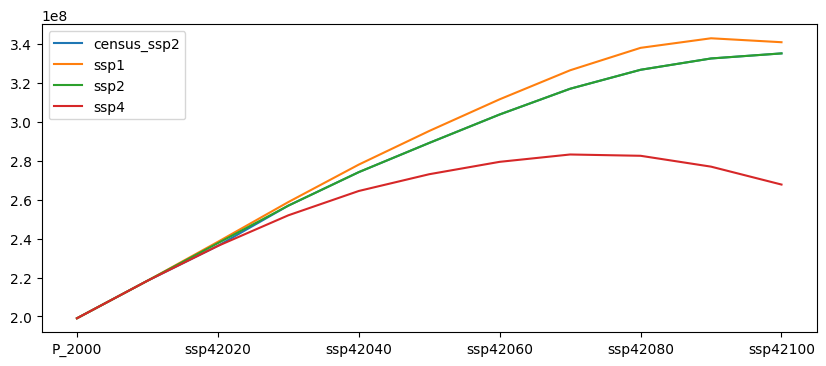

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
df_proj[[ 'P_2000', 'P_2010','CensusPop_20', 'ssp22030', 'ssp22040', 'ssp22050', 'ssp22060', 'ssp22070', 'ssp22080', 'ssp22090', 'ssp22100']].sum().plot(ax=ax)
df_proj[[ 'P_2000', 'P_2010','ssp12020', 'ssp12030', 'ssp12040', 'ssp12050', 'ssp12060','ssp12070', 'ssp12080', 'ssp12090', 'ssp12100']].sum().plot()
df_proj[[ 'P_2000', 'P_2010','ssp22020', 'ssp22030', 'ssp22040', 'ssp22050', 'ssp22060', 'ssp22070', 'ssp22080', 'ssp22090', 'ssp22100']].sum().plot()
df_proj[[ 'P_2000', 'P_2010','ssp42020', 'ssp42030', 'ssp42040', 'ssp42050', 'ssp42060','ssp42070', 'ssp42080', 'ssp42090', 'ssp42100']].sum().plot()
plt.legend(labels=['census_ssp2', 'ssp1', 'ssp2', 'ssp4'])



df_check = df_ACS.merge(df_population[['GEOID', 'CensusPop_20','ssp22020', 'ssp22030', 'ssp22040', 'ssp22050', 'ssp22060','ssp22070', 'ssp22080', 'ssp22090', 'ssp22100',
                                                                                 'ssp12020', 'ssp12030', 'ssp12040', 'ssp12050', 'ssp12060','ssp12070', 'ssp12080', 'ssp12090', 'ssp12100',
                                                                                 'ssp42020', 'ssp42030', 'ssp42040', 'ssp42050', 'ssp42060','ssp42070', 'ssp42080', 'ssp42090', 'ssp42100']], on ='GEOID', how='inner')
df_check = df_check.dropna()
# df_check.isna().sum()

df_check.isna().sum().sum()

ACS 241.706896
Census 244.534811
ssp2 245.99156907163695
ssp4 244.5061571957009
ssp1 246.68745720743644


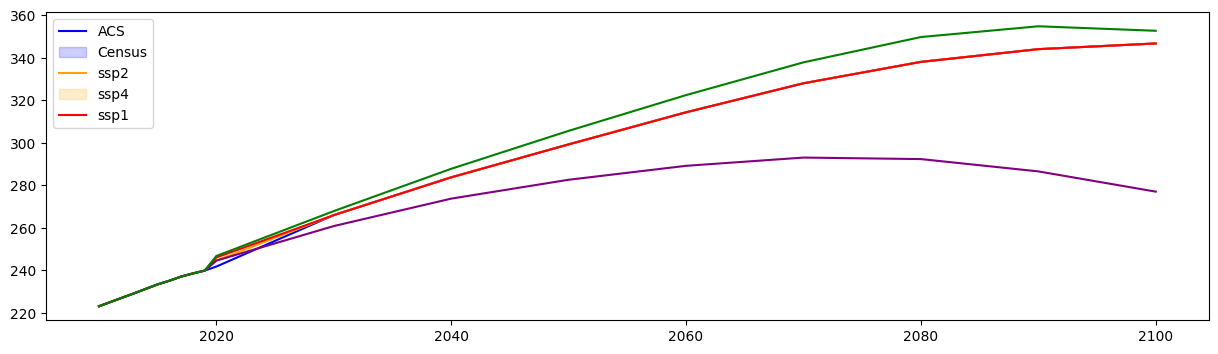

In [9]:
fig, ax = plt.subplots(figsize=(15, 4))
y_values = df_check[['Estimate!!SEX AND AGE!!Total population','Estimate!!SEX AND AGE!!Total populationY2011','Estimate!!SEX AND AGE!!Total populationY2012','Estimate!!SEX AND AGE!!Total populationY2013',
       'Estimate!!SEX AND AGE!!Total populationY2014','Estimate!!SEX AND AGE!!Total populationY2015','Estimate!!SEX AND AGE!!Total populationY2016','Estimate!!SEX AND AGE!!Total populationY2017',
       'Estimate!!SEX AND AGE!!Total populationY2018','Estimate!!SEX AND AGE!!Total populationY2019', 'Estimate!!SEX AND AGE!!Total populationY2020','ssp22030', 'ssp22040',
       'ssp22050', 'ssp22060', 'ssp22070', 'ssp22080', 'ssp22090', 'ssp22100']].sum()/1000000
print("ACS", y_values.values[10])
x_values = [2010, 2011, 2012,2013,2014,2015,2016,2017,2018,2019,2020,2030,2040,2050,2060,2070,2080,2090,2100]
sns.lineplot(x = x_values, y = y_values.values, color = 'blue')

y_values = df_check[['Estimate!!SEX AND AGE!!Total population','Estimate!!SEX AND AGE!!Total populationY2011','Estimate!!SEX AND AGE!!Total populationY2012','Estimate!!SEX AND AGE!!Total populationY2013',
       'Estimate!!SEX AND AGE!!Total populationY2014','Estimate!!SEX AND AGE!!Total populationY2015','Estimate!!SEX AND AGE!!Total populationY2016','Estimate!!SEX AND AGE!!Total populationY2017',
       'Estimate!!SEX AND AGE!!Total populationY2018','Estimate!!SEX AND AGE!!Total populationY2019', 'CensusPop_20','ssp22030', 'ssp22040','ssp22050', 'ssp22060', 'ssp22070', 'ssp22080', 'ssp22090', 'ssp22100']].sum()/1000000
print("Census",y_values.values[10])
x_values = [2010, 2011, 2012,2013,2014,2015,2016,2017,2018,2019,2020,2030,2040,2050,2060,2070,2080,2090,2100]
sns.lineplot(x = x_values, y = y_values.values, color = 'orange')

y_values = df_check[['Estimate!!SEX AND AGE!!Total population','Estimate!!SEX AND AGE!!Total populationY2011','Estimate!!SEX AND AGE!!Total populationY2012','Estimate!!SEX AND AGE!!Total populationY2013',
       'Estimate!!SEX AND AGE!!Total populationY2014','Estimate!!SEX AND AGE!!Total populationY2015','Estimate!!SEX AND AGE!!Total populationY2016','Estimate!!SEX AND AGE!!Total populationY2017',
       'Estimate!!SEX AND AGE!!Total populationY2018','Estimate!!SEX AND AGE!!Total populationY2019', 'ssp22020','ssp22030', 'ssp22040','ssp22050', 'ssp22060', 'ssp22070', 'ssp22080', 'ssp22090', 'ssp22100']].sum()/1000000
print("ssp2",y_values.values[10])
x_values = [2010, 2011, 2012,2013,2014,2015,2016,2017,2018,2019,2020,2030,2040,2050,2060,2070,2080,2090,2100]
sns.lineplot(x = x_values, y = y_values.values, color = 'red')

y_values = df_check[['Estimate!!SEX AND AGE!!Total population','Estimate!!SEX AND AGE!!Total populationY2011','Estimate!!SEX AND AGE!!Total populationY2012','Estimate!!SEX AND AGE!!Total populationY2013',
       'Estimate!!SEX AND AGE!!Total populationY2014','Estimate!!SEX AND AGE!!Total populationY2015','Estimate!!SEX AND AGE!!Total populationY2016','Estimate!!SEX AND AGE!!Total populationY2017',
       'Estimate!!SEX AND AGE!!Total populationY2018','Estimate!!SEX AND AGE!!Total populationY2019', 'ssp42020', 'ssp42030', 'ssp42040', 'ssp42050', 'ssp42060','ssp42070', 'ssp42080', 'ssp42090', 'ssp42100']].sum()/1000000
print("ssp4", y_values.values[10])
x_values = [2010, 2011, 2012,2013,2014,2015,2016,2017,2018,2019,2020,2030,2040,2050,2060,2070,2080,2090,2100]
sns.lineplot(x = x_values, y = y_values.values, color = 'purple')

y_values = df_check[['Estimate!!SEX AND AGE!!Total population','Estimate!!SEX AND AGE!!Total populationY2011','Estimate!!SEX AND AGE!!Total populationY2012','Estimate!!SEX AND AGE!!Total populationY2013',
       'Estimate!!SEX AND AGE!!Total populationY2014','Estimate!!SEX AND AGE!!Total populationY2015','Estimate!!SEX AND AGE!!Total populationY2016','Estimate!!SEX AND AGE!!Total populationY2017',
       'Estimate!!SEX AND AGE!!Total populationY2018','Estimate!!SEX AND AGE!!Total populationY2019','ssp12020', 'ssp12030', 'ssp12040', 'ssp12050', 'ssp12060','ssp12070', 'ssp12080', 'ssp12090', 'ssp12100']].sum()/1000000
print("ssp1", y_values.values[10])
x_values = [2010, 2011, 2012,2013,2014,2015,2016,2017,2018,2019,2020,2030,2040,2050,2060,2070,2080,2090,2100]
sns.lineplot(x = x_values, y = y_values.values, color = 'green')
plt.legend(labels=['ACS', 'Census', 'ssp2', 'ssp4', 'ssp1'])

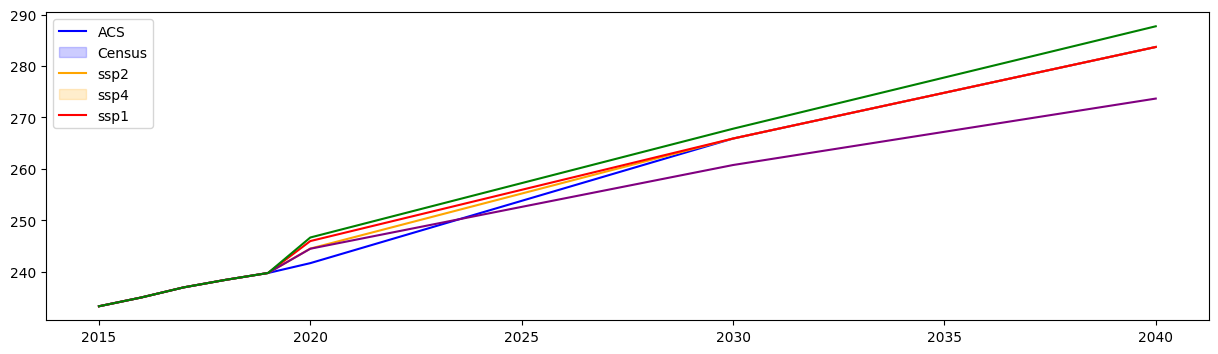

In [10]:
fig, ax = plt.subplots(figsize=(15, 4))
y_values = df_check[['Estimate!!SEX AND AGE!!Total populationY2015','Estimate!!SEX AND AGE!!Total populationY2016','Estimate!!SEX AND AGE!!Total populationY2017',
       'Estimate!!SEX AND AGE!!Total populationY2018','Estimate!!SEX AND AGE!!Total populationY2019', 'Estimate!!SEX AND AGE!!Total populationY2020','ssp22030', 'ssp22040']].sum()/1000000
# print("ACS", y_values.values[5])
x_values = [2015,2016,2017,2018,2019,2020,2030,2040]
sns.lineplot(x = x_values, y = y_values.values, color = 'blue')

y_values = df_check[['Estimate!!SEX AND AGE!!Total populationY2015','Estimate!!SEX AND AGE!!Total populationY2016','Estimate!!SEX AND AGE!!Total populationY2017',
       'Estimate!!SEX AND AGE!!Total populationY2018','Estimate!!SEX AND AGE!!Total populationY2019', 'CensusPop_20','ssp22030', 'ssp22040',]].sum()/1000000
# print("Census",y_values.values[10])
sns.lineplot(x = x_values, y = y_values.values, color = 'orange')

y_values = df_check[['Estimate!!SEX AND AGE!!Total populationY2015','Estimate!!SEX AND AGE!!Total populationY2016','Estimate!!SEX AND AGE!!Total populationY2017',
       'Estimate!!SEX AND AGE!!Total populationY2018','Estimate!!SEX AND AGE!!Total populationY2019', 'ssp22020','ssp22030', 'ssp22040']].sum()/1000000
# print("ssp2",y_values.values[10])
sns.lineplot(x = x_values, y = y_values.values, color = 'red')

y_values = df_check[['Estimate!!SEX AND AGE!!Total populationY2015','Estimate!!SEX AND AGE!!Total populationY2016','Estimate!!SEX AND AGE!!Total populationY2017',
       'Estimate!!SEX AND AGE!!Total populationY2018','Estimate!!SEX AND AGE!!Total populationY2019', 'ssp42020', 'ssp42030', 'ssp42040']].sum()/1000000
# print("ssp4", y_values.values[10])
sns.lineplot(x = x_values, y = y_values.values, color = 'purple')

y_values = df_check[['Estimate!!SEX AND AGE!!Total populationY2015','Estimate!!SEX AND AGE!!Total populationY2016','Estimate!!SEX AND AGE!!Total populationY2017',
       'Estimate!!SEX AND AGE!!Total populationY2018','Estimate!!SEX AND AGE!!Total populationY2019','ssp12020', 'ssp12030', 'ssp12040']].sum()/1000000
# print("ssp1", y_values.values[10])
sns.lineplot(x = x_values, y = y_values.values, color = 'green')
plt.legend(labels=['ACS', 'Census', 'ssp2', 'ssp4', 'ssp1'])

### How many places fluctuate between increase and decrease

In [11]:
# Total fluctuations in population over time
diff_population = df_population[['ssp22020', 'ssp22030', 'ssp22040', 'ssp22050', 'ssp22060','ssp22070', 'ssp22080', 'ssp22090', 'ssp22100']].diff(axis=1)
diff_wo_NAN = diff_population.drop(columns=['ssp22020']).dropna()
diff_wo_NAN
print("Changes in population over time: =====\n")
print("Time in Year")
print("  20~30  30~40  40~50  50~60  60~70  70~80  80~90  90~100")
print(np.where(diff_wo_NAN >= 0, 1, -1).sum(axis=0))

population_change_dir = np.where(diff_wo_NAN >= 0, 1, -1).sum(axis=1)

consistent, at_leat_one_fulctuation = 0, 0
# iterating each number in list
for num in population_change_dir:
     # checking condition
    if -8 < num < 8:
        at_leat_one_fulctuation += 1 
    else:
        consistent += 1
 
print("At least one fluctuation: ", at_leat_one_fulctuation)
print("Consistent increase of decrease: ", consistent)
print('\n')

print('Values in each group:==')
np.array(np.unique(population_change_dir, return_counts=True)).T

Changes in population over time: =====

Time in Year
  20~30  30~40  40~50  50~60  60~70  70~80  80~90  90~100
[  7624   1830  -1416    368   -748  -4580  -9574 -14018]
At least one fluctuation:  12479
Consistent increase of decrease:  19089


Values in each group:==


array([[   -8, 11031],
       [   -6,  2739],
       [   -4,  1557],
       [   -2,   823],
       [    0,   708],
       [    2,  1782],
       [    4,  2603],
       [    6,  2267],
       [    8,  8058]], dtype=int64)